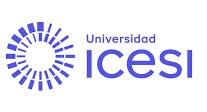

# Clasificación de Críticas de Cine con Embeddings y Redes Recurrentes
#Universidad ICESI

NLP - PROCESAMIENTO DE LENGUAJE NATURAL -
Profesor : Luis Ferro Diez
Cuaderno de normalizacion y patrones  en NLP - 3er semestre de 2026.
Presentado por : Edwin Perez -Rubén Darío Sabogal - Cristian Camilo Quebrada

---
## 0. Preparación del Entorno

Configuramos el entorno de ejecución, detectamos si estamos en Google Colab
y fijamos la semilla global para garantizar reproducibilidad de resultados.


In [1]:
import warnings
import os

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

try:
    import google.colab
    IN_COLAB = True
    print('Ejecutando en Google Colab')
except ImportError:
    IN_COLAB = False
    print('Ejecutando localmente')


Ejecutando en Google Colab


In [2]:
# Instalación condicional de dependencias en Colab
if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'datasets', 'torch',
                    'spacy', 'matplotlib', 'seaborn', 'wordcloud', 'scikit-learn'])
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_lg'])


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import random
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU disponible: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    torch.set_num_threads(min(4, os.cpu_count() or 1))
    print(f'Ejecutando en CPU con {torch.get_num_threads()} hilos')

print(f'Dispositivo: {device}')
print(f'Semilla global: {SEED}')

Ejecutando en CPU con 2 hilos
Dispositivo: cpu
Semilla global: 42


---
## 1. Exploración de Word Embeddings en Vocabulario Cinematográfico

Antes de construir clasificadores, exploramos cómo los embeddings preentrenados representan
el vocabulario de nuestro dominio. Usamos `spaCy` con `en_core_web_lg` (300 dimensiones,
entrenado sobre Common Crawl).

Este paso nos da **intuición sobre la semántica** que el modelo ya conoce antes de entrenar,
y responde la pregunta: ¿son los embeddings preentrenados útiles para el análisis de sentimiento en cine?


In [4]:
import spacy
from scipy.spatial.distance import cosine

# Cargamos el modelo grande de spaCy para inglés
# Contiene vectores densos de 300 dimensiones entrenados sobre Common Crawl
nlp = spacy.load('en_core_web_lg')
print(f'Vocabulario spaCy: {nlp.vocab.vectors.shape[0]:,} palabras × {nlp.vocab.vectors.shape[1]} dimensiones')


Vocabulario spaCy: 342,918 palabras × 300 dimensiones


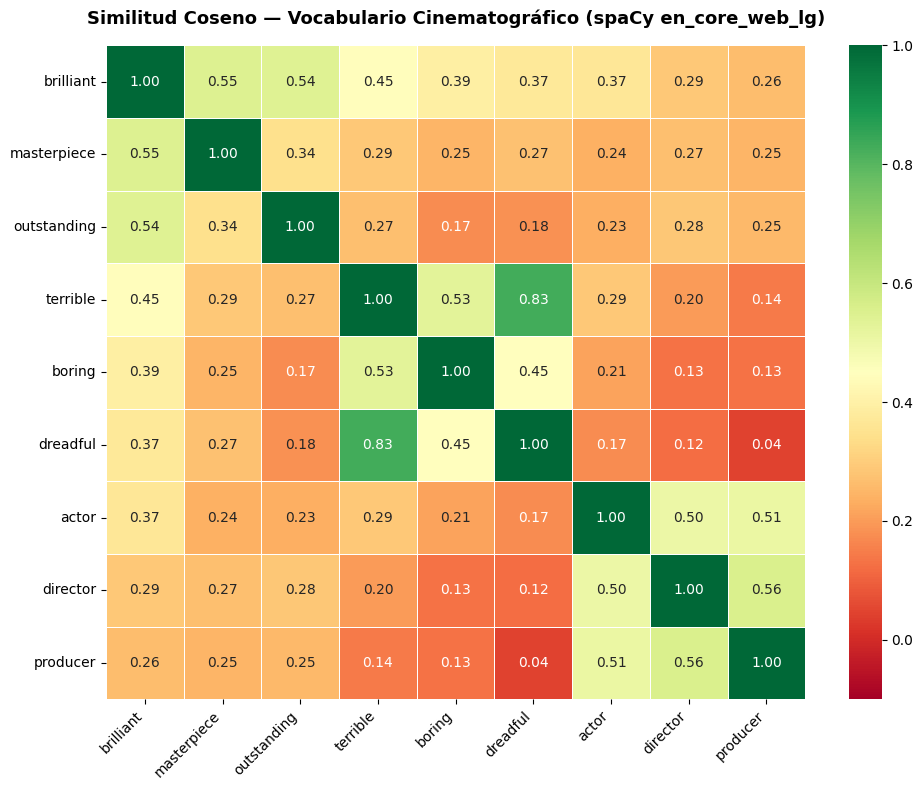

Observación clave:
• Palabras positivas tienen alta similitud ENTRE SÍ → cluster semántico
• Mismo comportamiento en negativas
• Diferencia con Notebook 3: love/hate=0.64 (mismo contexto), brilliant/boring son menos intercambiables


In [5]:
def similitud_coseno(v1, v2):
    """Similitud coseno entre dos vectores. Rango: [-1, 1]"""
    return 1 - cosine(v1, v2)

# Exploramos similitudes en vocabulario cinematográfico y de sentimiento
# Extendemos el ejemplo del Notebook 3 (lion/cat/pet) a nuestro dominio
grupos = {
    'Sentimiento positivo': ['brilliant', 'masterpiece', 'outstanding'],
    'Sentimiento negativo': ['terrible', 'boring', 'dreadful'],
    'Roles cinematog.':     ['actor', 'director', 'producer'],
}

todas = [w for g in grupos.values() for w in g]
n = len(todas)
sim_matrix = np.zeros((n, n))
for i, w1 in enumerate(todas):
    for j, w2 in enumerate(todas):
        v1 = nlp.vocab[w1].vector
        v2 = nlp.vocab[w2].vector
        if np.any(v1) and np.any(v2):
            sim_matrix[i, j] = similitud_coseno(v1, v2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=todas, yticklabels=todas,
            vmin=-0.1, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title('Similitud Coseno — Vocabulario Cinematográfico (spaCy en_core_web_lg)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Observación clave:')
print('• Palabras positivas tienen alta similitud ENTRE SÍ → cluster semántico')
print('• Mismo comportamiento en negativas')
print('• Diferencia con Notebook 3: love/hate=0.64 (mismo contexto),'
      ' brilliant/boring son menos intercambiables')


In [6]:
# ANALOGÍAS VECTORIALES en dominio cinematográfico
# Extendemos el ejemplo clásico del Notebook 3: king - man + woman ≈ queen
# pero aplicado al vocabulario de cine

print('=' * 65)
print('ANALOGÍAS VECTORIALES EN DOMINIO CINEMATOGRÁFICO')
print('Análogo a: rey - hombre + mujer = reina (Notebook 3)')
print('=' * 65)

analogias = [
    ('actor',    'man',      'woman',   'actress'),
    ('director', 'american', 'french',  'auteur'),
    ('comedy',   'funny',    'scary',   'thriller'),
]

for A, B, C, esperado in analogias:
    vA = nlp.vocab[A].vector
    vB = nlp.vocab[B].vector
    vC = nlp.vocab[C].vector
    resultado = vA - vB + vC

    similitudes = {}
    excluir = {A.lower(), B.lower(), C.lower()}
    for word in nlp.vocab:
        if (word.has_vector and word.is_lower and word.is_alpha
                and word.text not in excluir and len(word.text) > 2):
            sim = similitud_coseno(resultado, word.vector)
            if sim > 0.35:
                similitudes[word.text] = sim

    top3 = sorted(similitudes.items(), key=lambda x: x[1], reverse=True)[:3]
    sim_esp = similitud_coseno(resultado, nlp.vocab[esperado].vector)

    print(f'\n{A} - {B} + {C} = ?')
    print(f'  Top-3: {[(w, round(s,3)) for w, s in top3]}')
    print(f"  Similitud con '{esperado}': {sim_esp:.3f}")


ANALOGÍAS VECTORIALES EN DOMINIO CINEMATOGRÁFICO
Análogo a: rey - hombre + mujer = reina (Notebook 3)

actor - man + woman = ?
  Top-3: [('she', np.float32(0.453)), ('director', np.float32(0.442)), ('producer', np.float32(0.416))]
  Similitud con 'actress': 0.874

director - american + french = ?
  Top-3: [('producer', np.float32(0.443))]
  Similitud con 'auteur': 0.359

comedy - funny + scary = ?
  Top-3: [('dreadful', np.float32(0.458)), ('actor', np.float32(0.455)), ('terrible', np.float32(0.407))]
  Similitud con 'thriller': 0.672


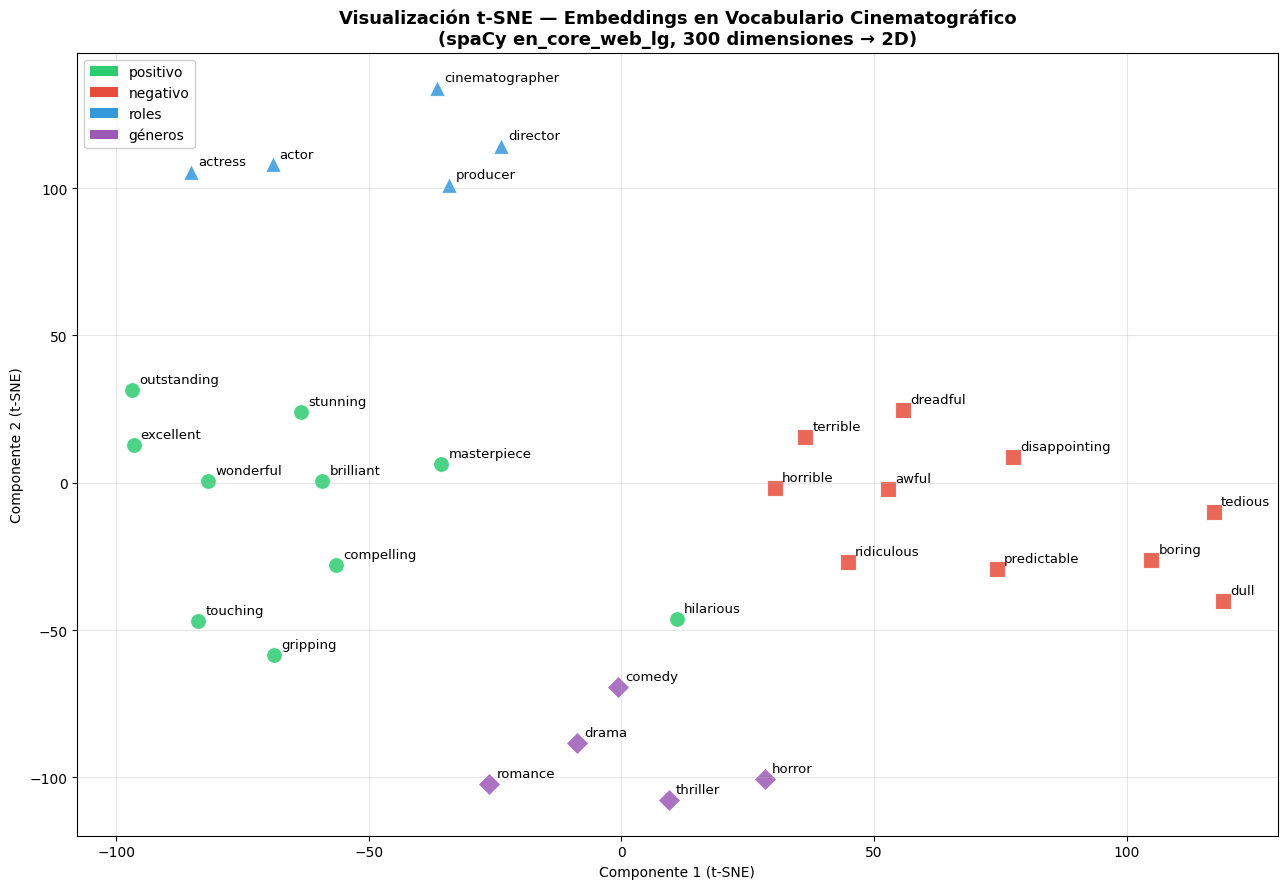

El t-SNE revela clusters naturales: las palabras de sentimiento positivo
y negativo tienden a agruparse separadamente, validando que los embeddings
preentrenados codifican información útil para nuestra tarea.


In [8]:
# Visualización t-SNE del espacio de embeddings en 2D
# Permite observar la organización geométrica de clusters semánticos
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches # Importación necesaria para mpatches

palabras_cine = [
    # Sentimiento positivo (10)
    'brilliant', 'masterpiece', 'outstanding', 'excellent', 'wonderful',
    'hilarious', 'touching', 'compelling', 'gripping', 'stunning',
    # Sentimiento negativo (10)
    'terrible', 'awful', 'boring', 'dreadful', 'disappointing',
    'predictable', 'tedious', 'dull', 'ridiculous', 'horrible',
    # Roles (5)
    'actor', 'actress', 'director', 'producer', 'cinematographer',
    # Géneros (5)
    'comedy', 'thriller', 'horror', 'drama', 'romance',
]
categorias = (['positivo'] * 10 + ['negativo'] * 10
              + ['roles'] * 5 + ['géneros'] * 5)

vectores = np.array([nlp.vocab[w].vector for w in palabras_cine])
tsne = TSNE(n_components=2, random_state=SEED, perplexity=8, n_iter=2000)
v2d = tsne.fit_transform(vectores)

fig, ax = plt.subplots(figsize=(13, 9))
colores   = {'positivo': '#2ecc71', 'negativo': '#e74c3c',
             'roles':    '#3498db', 'géneros':  '#9b59b6'}
marcadores = {'positivo': 'o', 'negativo': 's', 'roles': '^', 'géneros': 'D'}

for i, (palabra, cat) in enumerate(zip(palabras_cine, categorias)):
    x, y = v2d[i]
    ax.scatter(x, y, c=colores[cat], s=130, alpha=0.85,
               marker=marcadores[cat], edgecolors='white', linewidths=0.8)
    ax.annotate(palabra, (x, y), textcoords='offset points',
                xytext=(5, 5), fontsize=9.5)

leyenda = [mpatches.Patch(facecolor=colores[c], label=c) for c in colores]
ax.legend(handles=leyenda, loc='upper left', framealpha=0.9)
ax.set_title('Visualización t-SNE — Embeddings en Vocabulario Cinematográfico\n'
             '(spaCy en_core_web_lg, 300 dimensiones → 2D)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Componente 1 (t-SNE)')
ax.set_ylabel('Componente 2 (t-SNE)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('El t-SNE revela clusters naturales: las palabras de sentimiento positivo')
print('y negativo tienden a agruparse separadamente, validando que los embeddings')
print('preentrenados codifican información útil para nuestra tarea.')

---
## 2. Análisis Exploratorio de Datos (EDA) — Dataset IMDb

El **IMDb Large Movie Review Dataset** (Maas et al., 2011) contiene 50,000 críticas
cinematográficas en inglés, perfectamente balanceadas entre positivas y negativas.
Es uno de los benchmarks más citados en NLP para análisis de sentimiento.

**Diferencia con el notebook guía**: Allí el dataset tiene 12 categorías temáticas
claramente distinguibles por vocabulario. Aquí el reto es capturar el **tono subjetivo**
del texto — un problema inherentemente más ambiguo y desafiante.


In [9]:
from datasets import load_dataset

print('Cargando dataset IMDb desde HuggingFace Hub...')
imdb = load_dataset('stanfordnlp/imdb')

# PERFIL CPU: suficiente para demostrar el experimento sin tiempos excesivos.
SUBSET_TRAIN = 3000 if device.type == 'cpu' else 12000
SUBSET_TEST = 1000 if device.type == 'cpu' else 3000

print(f'Perfil: {"CPU" if device.type == "cpu" else "GPU"}')
print(f'Entrenamiento: {SUBSET_TRAIN:,} | Prueba: {SUBSET_TEST:,}')

train_raw = imdb['train']
test_raw = imdb['test']

rng = np.random.default_rng(SEED)
pos = np.where(np.array(train_raw['label']) == 1)[0]
neg = np.where(np.array(train_raw['label']) == 0)[0]
rng.shuffle(pos); rng.shuffle(neg)

n = SUBSET_TRAIN // 2
indices = np.concatenate([pos[:n], neg[:n]])
rng.shuffle(indices)

df_train = pd.DataFrame({
    'texto': [train_raw['text'][int(i)] for i in indices],
    'etiqueta': [train_raw['label'][int(i)] for i in indices],
})
df_train['sentimiento'] = df_train['etiqueta'].map({0: 'Negativo', 1: 'Positivo'})

pos_t = np.where(np.array(test_raw['label']) == 1)[0]
neg_t = np.where(np.array(test_raw['label']) == 0)[0]
rng.shuffle(pos_t); rng.shuffle(neg_t)
nt = SUBSET_TEST // 2
test_idx = np.concatenate([pos_t[:nt], neg_t[:nt]])
rng.shuffle(test_idx)

df_test = pd.DataFrame({
    'texto': [test_raw['text'][int(i)] for i in test_idx],
    'etiqueta': [test_raw['label'][int(i)] for i in test_idx],
})
df_test['sentimiento'] = df_test['etiqueta'].map({0: 'Negativo', 1: 'Positivo'})

print(f'Entrenamiento: {len(df_train):,} | Prueba: {len(df_test):,}')
print(df_train['sentimiento'].value_counts())

Cargando dataset IMDb desde HuggingFace Hub...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Perfil: CPU
Entrenamiento: 3,000 | Prueba: 1,000
Entrenamiento: 3,000 | Prueba: 1,000
sentimiento
Negativo    1500
Positivo    1500
Name: count, dtype: int64


In [10]:
# Ejemplos representativos de cada clase
print('=' * 70)
print('EJEMPLO DE CRÍTICA POSITIVA')
print('=' * 70)
ej_pos = df_train[df_train['etiqueta'] == 1]['texto'].iloc[0]
print(ej_pos[:600] + '...' if len(ej_pos) > 600 else ej_pos)

print('\n' + '=' * 70)
print('EJEMPLO DE CRÍTICA NEGATIVA')
print('=' * 70)
ej_neg = df_train[df_train['etiqueta'] == 0]['texto'].iloc[0]
print(ej_neg[:600] + '...' if len(ej_neg) > 600 else ej_neg)


EJEMPLO DE CRÍTICA POSITIVA
When I rented Domino I was expected it to be very dumb. I hate films that have really flashy editing and cinematography and Domino also just got very bad reviews. The only reason I watched it is because I like have liked Keira Knightley, Mickey Rourke, Christopher Walken, and Tony Scott on other occasions. I also just enjoy based on fact adventure stories. Yes the editing and cinematography were frantic, the story was weak, and the acting was mediocre, but I still loved this film for some bizarre reason. Domino was very, very entertaining and often very funny. It was horribly underrated when i...

EJEMPLO DE CRÍTICA NEGATIVA
ok. for starters, taxi driver is amazing. this, this is not taxi driver or amazing. what it is is bad. but i thought it was bad funny, which means that it did have some redeeming qualities. like the dialogue...wow. there was more or less no plot, the characters were all stupid, and the movie was preachy. there were some places were i tho

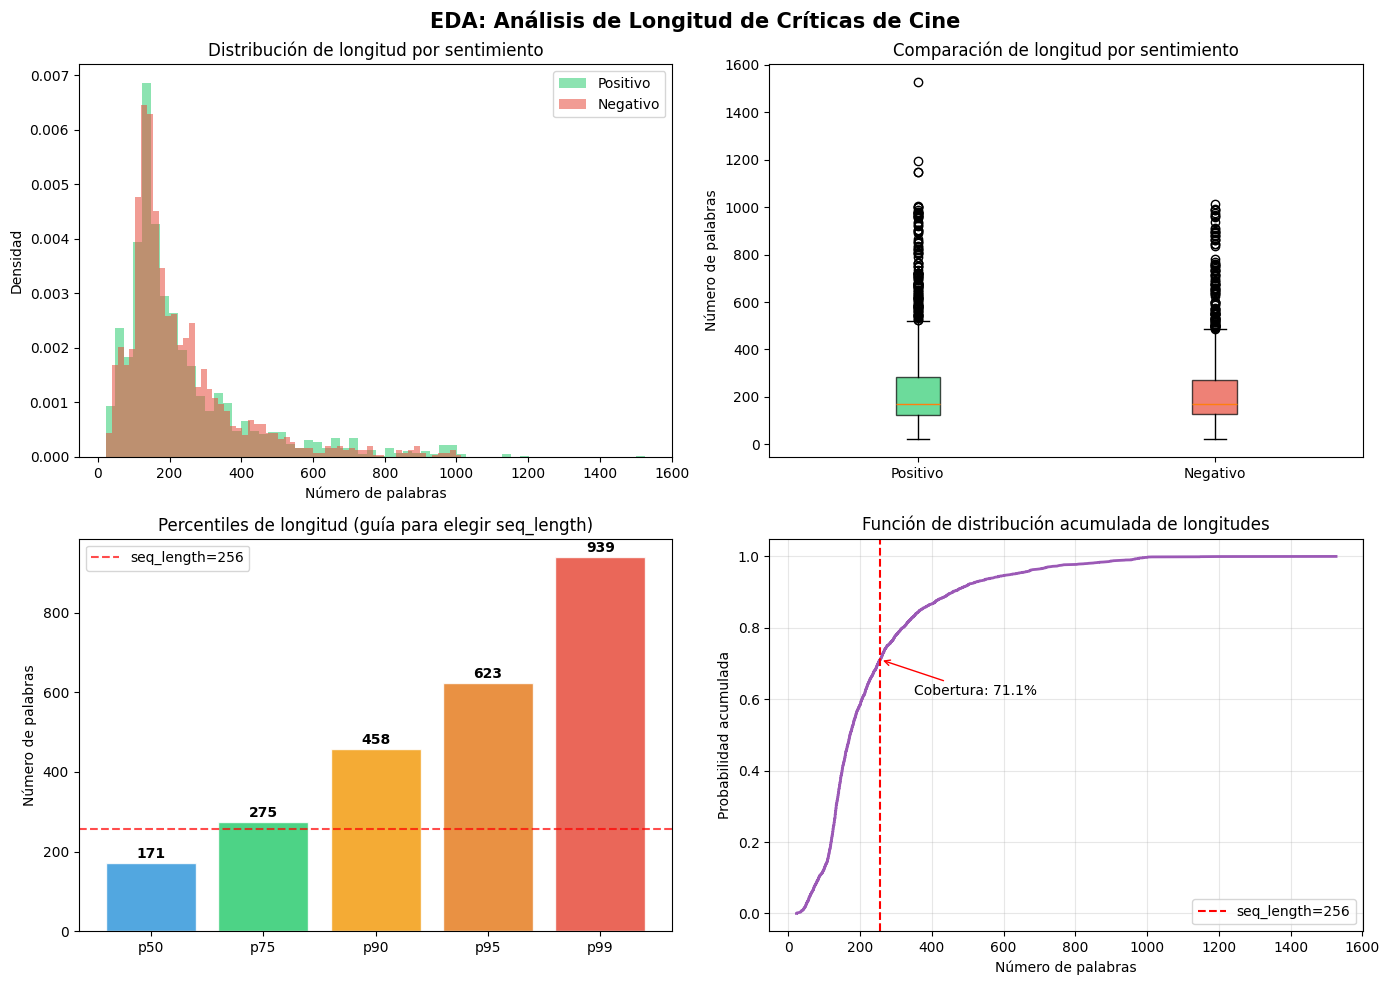

Estadísticas de longitud en palabras:
              count   mean    std   min    25%    50%    75%     max
sentimiento                                                         
Negativo     1500.0  226.7  161.7  22.0  128.0  172.0  271.0  1014.0
Positivo     1500.0  239.0  192.0  22.0  125.0  171.0  284.0  1527.0


In [11]:
# Análisis de longitud — fundamental para elegir seq_length
df_train['num_palabras'] = df_train['texto'].str.split().str.len()
df_test['num_palabras']  = df_test['texto'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA: Análisis de Longitud de Críticas de Cine',
             fontsize=15, fontweight='bold')

# Histograma por sentimiento
ax = axes[0, 0]
for lbl, color in [('Positivo', '#2ecc71'), ('Negativo', '#e74c3c')]:
    subset = df_train[df_train['sentimiento'] == lbl]['num_palabras']
    ax.hist(subset, bins=60, alpha=0.55, color=color, label=lbl, density=True)
ax.set_xlabel('Número de palabras'); ax.set_ylabel('Densidad')
ax.set_title('Distribución de longitud por sentimiento'); ax.legend()

# Boxplot comparativo
ax = axes[0, 1]
datos = [df_train[df_train['sentimiento'] == 'Positivo']['num_palabras'].values,
         df_train[df_train['sentimiento'] == 'Negativo']['num_palabras'].values]
bp = ax.boxplot(datos, labels=['Positivo', 'Negativo'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Número de palabras')
ax.set_title('Comparación de longitud por sentimiento')

# Percentiles — guía para elegir seq_length
ax = axes[1, 0]
pcts = [50, 75, 90, 95, 99]
vals = [np.percentile(df_train['num_palabras'], p) for p in pcts]
bars = ax.bar([f'p{p}' for p in pcts], vals,
              color=['#3498db','#2ecc71','#f39c12','#e67e22','#e74c3c'],
              alpha=0.85, edgecolor='white')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+5,
            f'{val:.0f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Número de palabras')
ax.set_title('Percentiles de longitud (guía para elegir seq_length)')
ax.axhline(256, color='red', linestyle='--', alpha=0.7, label='seq_length=256')
ax.legend()

# Distribución acumulada
ax = axes[1, 1]
sorted_len = np.sort(df_train['num_palabras'].values)
cumprob = np.arange(1, len(sorted_len)+1) / len(sorted_len)
ax.plot(sorted_len, cumprob, color='#9b59b6', linewidth=2)
ax.axvline(256, color='red', linestyle='--', label='seq_length=256')
y_at_256 = cumprob[np.searchsorted(sorted_len, 256)]
ax.annotate(f'Cobertura: {y_at_256:.1%}', xy=(256, y_at_256),
            xytext=(350, y_at_256-0.1), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='red'))
ax.set_xlabel('Número de palabras'); ax.set_ylabel('Probabilidad acumulada')
ax.set_title('Función de distribución acumulada de longitudes')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Estadísticas de longitud en palabras:')
print(df_train.groupby('sentimiento')['num_palabras'].describe().round(1))


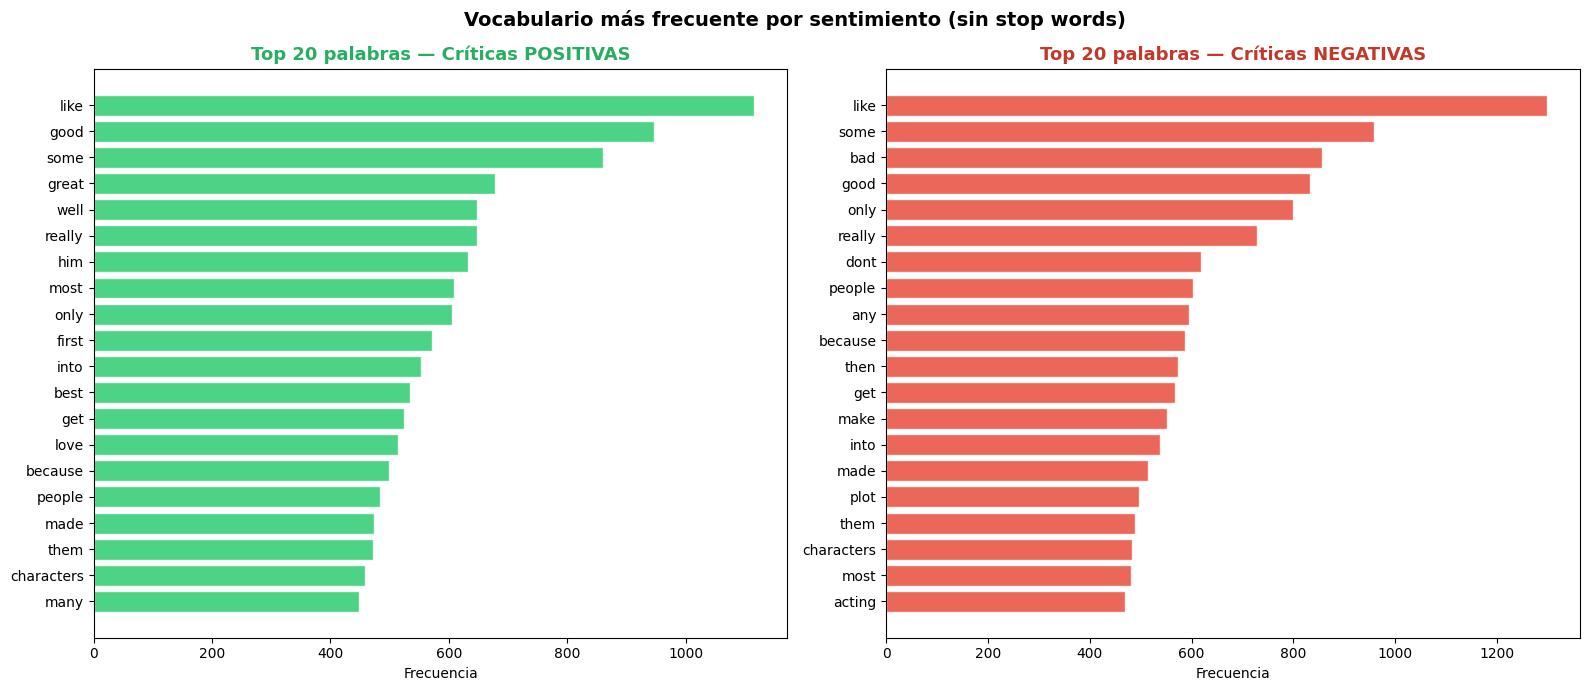

Solo en Top-100 positivo: ['family', 'work', 'without', 'find', 'makes', 'own', 'quite', 'series', 'both', 'always', 'may', 'cast']
Solo en Top-100 negativo: ['going', 'however', 'least', 'thing', 'fact', 'anything', 'enough', 'ive', 'bad', 'got', 'thats', 'nothing']


In [12]:
# Análisis de palabras más frecuentes por sentimiento
# Revela el vocabulario diferenciador de cada clase

STOP_WORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with','by',
    'from','is','was','are','were','be','been','this','that','it','he','she',
    'they','his','her','its','their','i','me','my','we','you','your','as',
    'not','no','so','if','have','has','had','do','does','did','can','could',
    'would','will','what','which','who','when','where','how','all','one',
    'more','about','up','out','there','just','also','than','other','very',
    'even','much','too','film','movie','movies','films','story','see','time'
}

def palabras_frecuentes(textos, n=25):
    contador = Counter()
    for t in textos:
        palabras = re.sub(r'[^a-z\s]', '', t.lower()).split()
        contador.update([w for w in palabras if w not in STOP_WORDS and len(w) > 2])
    return contador.most_common(n)

textos_pos = df_train[df_train['etiqueta'] == 1]['texto'].tolist()
textos_neg = df_train[df_train['etiqueta'] == 0]['texto'].tolist()

top_pos = palabras_frecuentes(textos_pos, 20)
top_neg = palabras_frecuentes(textos_neg, 20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

pal_p, cnt_p = zip(*top_pos)
bars = ax1.barh(pal_p, cnt_p, color='#2ecc71', alpha=0.85, edgecolor='white')
ax1.set_xlabel('Frecuencia')
ax1.set_title('Top 20 palabras — Críticas POSITIVAS',
              fontsize=13, fontweight='bold', color='#27ae60')
ax1.invert_yaxis()

pal_n, cnt_n = zip(*top_neg)
bars = ax2.barh(pal_n, cnt_n, color='#e74c3c', alpha=0.85, edgecolor='white')
ax2.set_xlabel('Frecuencia')
ax2.set_title('Top 20 palabras — Críticas NEGATIVAS',
              fontsize=13, fontweight='bold', color='#c0392b')
ax2.invert_yaxis()

plt.suptitle('Vocabulario más frecuente por sentimiento (sin stop words)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Palabras exclusivas de cada clase (entre las top 100)
set_pos = set(w for w, _ in palabras_frecuentes(textos_pos, 100))
set_neg = set(w for w, _ in palabras_frecuentes(textos_neg, 100))
print('Solo en Top-100 positivo:', list(set_pos - set_neg)[:12])
print('Solo en Top-100 negativo:', list(set_neg - set_pos)[:12])


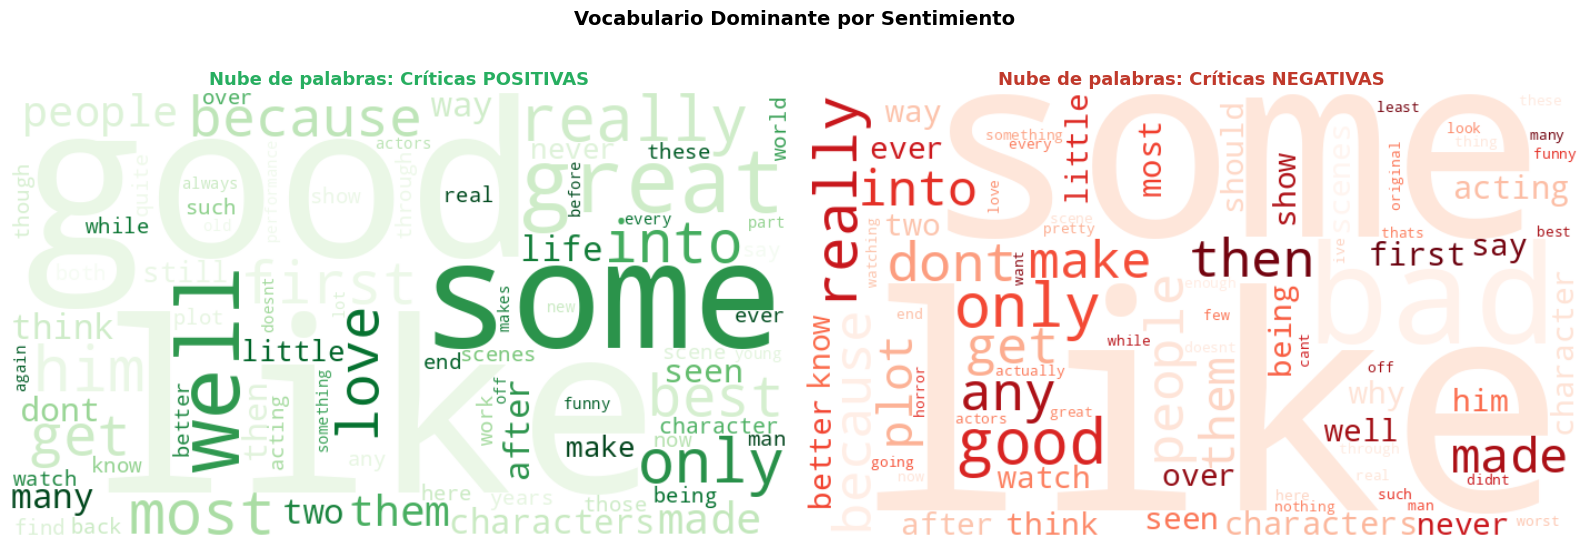

In [13]:
# Nube de palabras — visualización intuitiva del vocabulario dominante
try:
    from wordcloud import WordCloud
    TIENE_WC = True
except ImportError:
    TIENE_WC = False
    print('wordcloud no instalado. Instalar con: pip install wordcloud')

if TIENE_WC:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    freq_pos = dict(palabras_frecuentes(textos_pos, 200))
    freq_neg = dict(palabras_frecuentes(textos_neg, 200))

    wc_pos = WordCloud(width=700, height=400, background_color='white',
                       colormap='Greens', max_words=80, random_state=SEED)
    wc_pos.generate_from_frequencies(freq_pos)
    ax1.imshow(wc_pos, interpolation='bilinear'); ax1.axis('off')
    ax1.set_title('Nube de palabras: Críticas POSITIVAS',
                  fontsize=13, fontweight='bold', color='#27ae60')

    wc_neg = WordCloud(width=700, height=400, background_color='white',
                       colormap='Reds', max_words=80, random_state=SEED)
    wc_neg.generate_from_frequencies(freq_neg)
    ax2.imshow(wc_neg, interpolation='bilinear'); ax2.axis('off')
    ax2.set_title('Nube de palabras: Críticas NEGATIVAS',
                  fontsize=13, fontweight='bold', color='#c0392b')

    plt.suptitle('Vocabulario Dominante por Sentimiento', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


---
## 3. Preparación del Pipeline de Datos

Construimos el tokenizador y los DataLoaders de PyTorch.
A diferencia del Notebook guía, aquí eliminamos las etiquetas HTML
que el dataset IMDb incluye en muchas reseñas, y elegimos `seq_length`
basándonos directamente en los percentiles calculados en el EDA.


In [14]:
def tokenizar(texto: str) -> list:
    """Tokenizador para reseñas en inglés.
    - Elimina tags HTML residuales del dataset IMDb
    - Convierte a minúsculas y mantiene solo letras
    """
    texto = re.sub(r'<[^>]+>', ' ', texto)   # Eliminar HTML
    texto = texto.lower()
    texto = re.sub(r'[^a-z\s]', ' ', texto)  # Solo letras
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto.split()

# Construcción del vocabulario a partir de los textos de entrenamiento
MAX_VOCAB = 15000
print(f'Construyendo vocabulario (máximo {MAX_VOCAB:,} tokens)...')

conteo_tokens = Counter()
for texto in df_train['texto']:
    conteo_tokens.update(tokenizar(texto))

print(f'Tokens únicos encontrados: {len(conteo_tokens):,}')

# Vocabulario con tokens más frecuentes (mínimo 2 ocurrencias)
tokens_top = [tok for tok, cnt in conteo_tokens.most_common(MAX_VOCAB - 2) if cnt >= 2]
vocab = {'[PAD]': 0, '[UNK]': 1}
for tok in tokens_top:
    vocab[tok] = len(vocab)

id_a_token = {v: k for k, v in vocab.items()}
print(f'Vocabulario final: {len(vocab):,} tokens')
print(f'Top 15 palabras más frecuentes:')
print([t for t, _ in conteo_tokens.most_common(15)])


Construyendo vocabulario (máximo 15,000 tokens)...
Tokens únicos encontrados: 30,161
Vocabulario final: 15,000 tokens
Top 15 palabras más frecuentes:
['the', 'and', 'a', 'of', 'to', 'is', 'it', 'in', 'i', 'this', 'that', 's', 'was', 'as', 'movie']


In [15]:
# Perfil CPU: reduce el costo de las redes recurrentes.
SEQ_LENGTH = 160

def codificar_texto(texto: str, max_len: int = SEQ_LENGTH) -> list:
    tokens = tokenizar(texto)[:max_len]
    ids = [vocab.get(t, vocab['[UNK]']) for t in tokens]
    ids += [vocab['[PAD]']] * (max_len - len(ids))
    return ids

prueba = 'This movie was absolutely brilliant! The cinematography was stunning.'
ids_p = codificar_texto(prueba, max_len=10)
tok_p = [id_a_token.get(i, '[?]') for i in ids_p]

print(f'SEQ_LENGTH: {SEQ_LENGTH} (optimizado para CPU)')
print('Texto:', prueba)
print('Tokens/IDs:', list(zip(tok_p, ids_p)))

SEQ_LENGTH: 160 (optimizado para CPU)
Texto: This movie was absolutely brilliant! The cinematography was stunning.
Tokens/IDs: [('this', 11), ('movie', 16), ('was', 14), ('absolutely', 412), ('brilliant', 511), ('the', 2), ('cinematography', 582), ('was', 14), ('stunning', 1178), ('[PAD]', 0)]


In [16]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class ConjuntoDatosIMDb(Dataset):
    """Dataset que conserva secuencias sin padding global."""
    def __init__(self, textos, etiquetas, max_len=SEQ_LENGTH):
        self.textos = list(textos)
        self.etiquetas = list(etiquetas)
        self.max_len = max_len

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        tokens = tokenizar(self.textos[idx])[:self.max_len]
        if not tokens:
            tokens = ['[UNK]']
        ids = [vocab.get(t, vocab['[UNK]']) for t in tokens]
        return {'input_ids': torch.tensor(ids, dtype=torch.long),
                'etiqueta': torch.tensor(self.etiquetas[idx], dtype=torch.long)}

def collate_fn(batch):
    """Padding dinámico: cada lote se rellena solo hasta su secuencia más larga."""
    secuencias = [x['input_ids'] for x in batch]
    etiquetas = torch.stack([x['etiqueta'] for x in batch])
    longitudes = torch.tensor([len(x) for x in secuencias], dtype=torch.long)
    ids = nn.utils.rnn.pad_sequence(secuencias, batch_first=True,
                                    padding_value=vocab['[PAD]'])
    return {'input_ids': ids, 'etiqueta': etiquetas, 'longitudes': longitudes}

# División estratificada: preserva la proporción positivo/negativo
train_textos, val_textos, train_y, val_y = train_test_split(
    df_train['texto'], df_train['etiqueta'],
    test_size=0.10, random_state=SEED, stratify=df_train['etiqueta']
)

ds_train = ConjuntoDatosIMDb(train_textos, train_y)
ds_val   = ConjuntoDatosIMDb(val_textos, val_y)
ds_prueba = ConjuntoDatosIMDb(df_test['texto'], df_test['etiqueta'])

BATCH = 16 if device.type == 'cpu' else 64
loader_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
loader_val = DataLoader(ds_val, batch_size=BATCH, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)
loader_test = DataLoader(ds_prueba, batch_size=BATCH, shuffle=False,
                         collate_fn=collate_fn, num_workers=0)

print(f'Entrenamiento: {len(ds_train):,} | Validación: {len(ds_val):,} | Prueba: {len(ds_prueba):,}')
print(f'Batch size: {BATCH} | Padding dinámico: activado ✓')


Entrenamiento: 2,700 | Validación: 300 | Prueba: 1,000
Batch size: 16 | Padding dinámico: activado ✓


---
## 4. Infraestructura de Entrenamiento

Definimos funciones reutilizables de entrenamiento y evaluación.
Las aplicaremos a los tres modelos para garantizar una comparación justa.

Características de la infraestructura:
- **Early stopping**: Detiene el entrenamiento si el `val_loss` no mejora
- **Gradient clipping**: Evita el problema de gradientes explosivos
- **Learning rate scheduling**: Reduce el lr si el `val_loss` se estanca
- **Restauración del mejor estado**: Al finalizar, cargamos los pesos del mejor checkpoint


In [17]:
import time
from sklearn.metrics import classification_report, confusion_matrix

def entrenar_epoca(modelo, loader, opt, criterio):
    """Ejecuta una época completa de entrenamiento."""
    modelo.train()
    total_loss = total_correct = total_n = 0
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        etiq = batch['etiqueta'].to(device)
        opt.zero_grad()
        sal   = modelo(ids, batch.get('longitudes'))
        logits = sal[0] if isinstance(sal, tuple) else sal
        loss   = criterio(logits, etiq)
        loss.backward()
        nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)  # Gradient clipping
        opt.step()
        total_loss    += loss.item() * etiq.size(0)
        total_correct += (logits.argmax(1) == etiq).sum().item()
        total_n       += etiq.size(0)
    return total_loss / total_n, total_correct / total_n


def evaluar(modelo, loader, criterio):
    """Evalúa el modelo sobre un DataLoader dado."""
    modelo.eval()
    total_loss = total_correct = total_n = 0
    preds_total, etiq_total, probs_total = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            etiq = batch['etiqueta'].to(device)
            sal  = modelo(ids, batch.get('longitudes'))
            logits = sal[0] if isinstance(sal, tuple) else sal
            loss   = criterio(logits, etiq)
            preds  = logits.argmax(1)
            total_loss    += loss.item() * etiq.size(0)
            total_correct += (preds == etiq).sum().item()
            total_n       += etiq.size(0)
            preds_total.extend(preds.cpu().numpy())
            probs_total.extend(F.softmax(logits, dim=1)[:, 1].cpu().numpy())
            etiq_total.extend(etiq.cpu().numpy())
    return total_loss / total_n, total_correct / total_n, preds_total, etiq_total, probs_total


def entrenar_modelo(modelo, loader_train, loader_val,
                    epocas, lr=1e-3, paciencia=3, nombre='Modelo'):
    """Entrena con early stopping y scheduler de lr.
    Retorna historial de métricas y número de parámetros.
    """
    modelo = modelo.to(device)
    opt    = torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-5)
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', patience=2, factor=0.5)
    crit   = nn.CrossEntropyLoss()

    hist = []
    mejor_val  = float('inf')
    mejor_est  = None
    contador   = 0
    n_params   = sum(p.numel() for p in modelo.parameters() if p.requires_grad)

    print(f'\n{"="*60}')
    print(f'Entrenando: {nombre}')
    print(f'Parámetros entrenables: {n_params:,}')
    print(f'{"="*60}')
    print(f'{"Época":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>8}')
    print('-' * 60)

    for ep in range(epocas):
        tl, ta = entrenar_epoca(modelo, loader_train, opt, crit)
        vl, va, _, _, _ = evaluar(modelo, loader_val, crit)
        sched.step(vl)
        hist.append({'epoca': ep+1, 'train_loss': tl, 'train_acc': ta,
                     'val_loss': vl, 'val_acc': va})
        print(f'{ep+1:>6} | {tl:>10.4f} | {ta:>9.4f} | {vl:>8.4f} | {va:>8.4f}')

        if vl < mejor_val:
            mejor_val = vl
            mejor_est = {k: v.clone() for k, v in modelo.state_dict().items()}
            contador  = 0
        else:
            contador += 1
            if contador >= paciencia:
                print(f'\n⚡ Early stopping en época {ep+1} (paciencia={paciencia})')
                break

    if mejor_est:
        modelo.load_state_dict(mejor_est)
    print(f'Mejor val_loss: {mejor_val:.4f}')
    return pd.DataFrame(hist), n_params


def graficar_historial(historiales, nombres):
    """Grafica curvas de aprendizaje comparativas de múltiples modelos."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colores = ['#3498db', '#e74c3c', '#2ecc71']
    for hist, nombre, color in zip(historiales, nombres, colores):
        ep = hist['epoca']
        axes[0].plot(ep, hist['train_loss'], '--', color=color, alpha=0.5)
        axes[0].plot(ep, hist['val_loss'],   '-',  color=color, linewidth=2.5,
                     label=f'{nombre} (val)')
        axes[1].plot(ep, hist['train_acc'],  '--', color=color, alpha=0.5)
        axes[1].plot(ep, hist['val_acc'],    '-',  color=color, linewidth=2.5)
    for nombre, color in zip(nombres, colores):
        axes[1].plot([], [], '-', color=color, linewidth=2.5, label=nombre)
    for ax, titulo, ylabel in [
        (axes[0], 'Pérdida (Loss) durante entrenamiento',  'Cross-Entropy Loss'),
        (axes[1], 'Exactitud (Accuracy) durante entrenamiento', 'Accuracy')
    ]:
        ax.set_title(titulo, fontweight='bold')
        ax.set_xlabel('Época'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.suptitle('Historial de Entrenamiento — Comparación de Modelos',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print('Infraestructura de entrenamiento definida ✓')


Infraestructura de entrenamiento definida ✓


## ⚙️ Perfil optimizado para CPU

Este notebook está diseñado para ejecutarse en un computador personal **sin TPU**.

- **No requiere TPU**.
- GPU opcional.
- 3.000 reseñas de entrenamiento y 1.000 de prueba en CPU.
- Vocabulario máximo: **15.000**.
- Secuencias de máximo **160 tokens**.
- Embeddings de **64 dimensiones**.
- Estado oculto de **96 unidades**.
- Máximo **5 épocas** y *early stopping*.
- *Padding dinámico* para evitar cálculos innecesarios.

La prioridad es una comparación metodológica sólida y reproducible, con un costo computacional razonable.


---
## 5. Modelo 1: LSTM Simple (Línea Base)

El primer modelo es nuestra **línea base**: una LSTM unidireccional equivalente
al clasificador del Notebook 3, adaptada aquí a análisis de sentimiento binario.

**Arquitectura**: `Embedding → LSTM (unidireccional) → último h_T → Linear`

**Limitación clave**: Solo lee el texto de izquierda a derecha. Para oraciones con
negaciones tardías como *'This was, despite expectations, not a good movie'*,
el modelo debe recordar el `not` durante muchos pasos temporales.


In [18]:
VOCAB_SIZE = len(vocab)

class ClasificadorLSTM(nn.Module):
    """
    Clasificador LSTM unidireccional — Línea Base.
    Equivalente al modelo del Notebook 3 adaptado a sentimiento binario.

    Flujo:
        input_ids → Embedding → LSTM → h_T (último estado) → Linear → logits
    """
    def __init__(self, vocab_size, num_clases=2, dim_emb=64,
                 dim_oculto=96, num_capas=1, dropout=0.25):
        super().__init__()
        self.embedding    = nn.Embedding(vocab_size, dim_emb, padding_idx=0)
        self.lstm         = nn.LSTM(dim_emb, dim_oculto, num_layers=num_capas,
                                   batch_first=True,
                                   dropout=dropout if num_capas > 1 else 0.0,
                                   bidirectional=False)   # ← Unidireccional
        self.dropout      = nn.Dropout(dropout)
        self.clasificador = nn.Linear(dim_oculto, num_clases)

    def forward(self, input_ids, longitudes=None):
        emb = self.dropout(self.embedding(input_ids))  # [B, L, E]
        if longitudes is not None:
            packed = nn.utils.rnn.pack_padded_sequence(emb, longitudes.cpu(), batch_first=True, enforce_sorted=False)
            _, (h, _) = self.lstm(packed)
        else:
            _, (h, _) = self.lstm(emb)                     # h: [num_capas, B, H]
        ultimo_h  = self.dropout(h[-1])                # [B, H]
        return self.clasificador(ultimo_h)             # [B, num_clases]

modelo_lstm = ClasificadorLSTM(VOCAB_SIZE)
print(modelo_lstm)
print(f'\nParámetros totales: {sum(p.numel() for p in modelo_lstm.parameters()):,}')


ClasificadorLSTM(
  (embedding): Embedding(15000, 64, padding_idx=0)
  (lstm): LSTM(64, 96, batch_first=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (clasificador): Linear(in_features=96, out_features=2, bias=True)
)

Parámetros totales: 1,022,402


In [19]:
EPOCAS = 5

hist_lstm, params_lstm = entrenar_modelo(
    modelo_lstm, loader_train, loader_val,
    epocas=EPOCAS, lr=1e-3, paciencia=2, nombre='LSTM Simple'
)



Entrenando: LSTM Simple
Parámetros entrenables: 1,022,402
 Época | Train Loss | Train Acc | Val Loss |  Val Acc
------------------------------------------------------------
     1 |     0.6932 |    0.5093 |   0.6941 |   0.5167
     2 |     0.6669 |    0.5870 |   0.6899 |   0.5600
     3 |     0.6347 |    0.6385 |   0.6923 |   0.5733
     4 |     0.5859 |    0.6915 |   0.6641 |   0.6067
     5 |     0.5099 |    0.7552 |   0.7146 |   0.6267
Mejor val_loss: 0.6641


In [20]:
criterio = nn.CrossEntropyLoss()
loss_lstm, acc_lstm, preds_lstm, etiq_lstm, probs_lstm = evaluar(modelo_lstm, loader_test, criterio)

print(f'LSTM Simple — Test Loss: {loss_lstm:.4f} | Test Accuracy: {acc_lstm:.4f}')
print('\nReporte de clasificación:')
print(classification_report(etiq_lstm, preds_lstm,
                             target_names=['Negativo', 'Positivo']))


LSTM Simple — Test Loss: 0.6768 | Test Accuracy: 0.5870

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.58      0.61      0.60       500
    Positivo       0.59      0.56      0.58       500

    accuracy                           0.59      1000
   macro avg       0.59      0.59      0.59      1000
weighted avg       0.59      0.59      0.59      1000



---
## 6. Modelo 2: GRU Bidireccional

Las **GRU** (Chung et al., 2014) son una alternativa simplificada a las LSTM.
Usan solo dos compuertas (*reset* y *update*) en lugar de tres, reduciendo
el número de parámetros ~25% con resultados comparables.

**¿Por qué incluir GRU en la comparación?**
- Menor costo computacional → entrenamiento más rápido
- Al hacerla **bidireccional**, ve el texto completo antes de decidir
- Es una alternativa legítima que todo profesional de NLP debe conocer

**Arquitectura**: `Embedding → GRU bidireccional → concat(fwd, bwd) → Linear`


In [21]:
class ClasificadorGRU(nn.Module):
    """
    Clasificador GRU Bidireccional.

    La GRU simplifica la LSTM eliminando el estado de celda (c_t):
    - Compuerta de reset (r): qué olvidar del estado previo
    - Compuerta de actualización (z): mezcla estado previo y nuevo candidato

    La bidireccionalidad agrega una segunda GRU que lee la secuencia al revés,
    duplicando la representación y capturando contexto futuro también.
    """
    def __init__(self, vocab_size, num_clases=2, dim_emb=64,
                 dim_oculto=96, num_capas=1, dropout=0.25):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, dim_emb, padding_idx=0)
        self.gru       = nn.GRU(dim_emb, dim_oculto, num_layers=num_capas,
                                batch_first=True,
                                dropout=dropout if num_capas > 1 else 0.0,
                                bidirectional=True)   # ← Bidireccional
        self.dropout   = nn.Dropout(dropout)
        # *2 porque concatenamos dirección forward + backward
        self.clasificador = nn.Linear(dim_oculto * 2, num_clases)

    def forward(self, input_ids, longitudes=None):
        emb = self.dropout(self.embedding(input_ids))
        if longitudes is not None:
            packed = nn.utils.rnn.pack_padded_sequence(emb, longitudes.cpu(), batch_first=True, enforce_sorted=False)
            _, h = self.gru(packed)
        else:
            _, h = self.gru(emb)   # h: [num_capas*2, B, H]
        fwd  = h[-2]           # Última capa, dirección forward
        bwd  = h[-1]           # Última capa, dirección backward
        comb = torch.cat([fwd, bwd], dim=1)   # [B, 2H]
        return self.clasificador(self.dropout(comb))

modelo_gru = ClasificadorGRU(VOCAB_SIZE)
print(modelo_gru)
print(f'\nParámetros totales: {sum(p.numel() for p in modelo_gru.parameters()):,}')
print('\nNota: ~25% menos parámetros que LSTM equivalente (sin estado de celda)')


ClasificadorGRU(
  (embedding): Embedding(15000, 64, padding_idx=0)
  (gru): GRU(64, 96, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (clasificador): Linear(in_features=192, out_features=2, bias=True)
)

Parámetros totales: 1,053,698

Nota: ~25% menos parámetros que LSTM equivalente (sin estado de celda)


In [22]:
hist_gru, params_gru = entrenar_modelo(
    modelo_gru, loader_train, loader_val,
    epocas=EPOCAS, lr=1e-3, paciencia=2, nombre='GRU Bidireccional'
)



Entrenando: GRU Bidireccional
Parámetros entrenables: 1,053,698
 Época | Train Loss | Train Acc | Val Loss |  Val Acc
------------------------------------------------------------
     1 |     0.6930 |    0.5352 |   0.6797 |   0.5800
     2 |     0.6586 |    0.6004 |   0.6452 |   0.6267
     3 |     0.5942 |    0.6844 |   0.6532 |   0.6333
     4 |     0.5106 |    0.7452 |   0.6176 |   0.6733
     5 |     0.4214 |    0.8026 |   0.6635 |   0.7067
Mejor val_loss: 0.6176


In [23]:
loss_gru, acc_gru, preds_gru, etiq_gru, probs_gru = evaluar(modelo_gru, loader_test, criterio)
print(f'GRU Bidireccional — Test Loss: {loss_gru:.4f} | Test Accuracy: {acc_gru:.4f}')
print('\nReporte de clasificación:')
print(classification_report(etiq_gru, preds_gru,
                             target_names=['Negativo', 'Positivo']))


GRU Bidireccional — Test Loss: 0.6143 | Test Accuracy: 0.6880

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.69      0.67      0.68       500
    Positivo       0.68      0.70      0.69       500

    accuracy                           0.69      1000
   macro avg       0.69      0.69      0.69      1000
weighted avg       0.69      0.69      0.69      1000



---
## 7. Modelo 3: BiLSTM con Mecanismo de Atención de Bahdanau 🌟

Esta es la arquitectura más avanzada del notebook, que **va más allá de los notebooks guía**.

### ¿Por qué la atención mejora el análisis de sentimiento?

En LSTM/GRU simple, toda la información se comprime en **un único vector** (h_T).
Esto es problemático para textos largos donde palabras críticas aparecen en el medio.

El mecanismo de **atención de Bahdanau (2015)** permite al modelo:
1. Calcular una **puntuación de relevancia** para cada posición en la secuencia
2. Crear una **representación ponderada** que da más peso a las palabras importantes
3. Ser **interpretable**: podemos visualizar a qué palabras 'atendió' el modelo

Fórmula de atención:
$$\text{score}(t) = v^\top \cdot \tanh(W \cdot h_t + b)$$
$$\alpha_t = \text{softmax}(\text{score}(t))$$
$$\text{contexto} = \sum_t \alpha_t \cdot h_t$$

**Arquitectura**: `Embedding → BiLSTM → Atención → Suma ponderada → MLP → Logits`


In [24]:
class AtenciónBahdanau(nn.Module):
    """
    Mecanismo de atención aditiva (Bahdanau et al., 2015).

    Para cada posición t de la secuencia:
        score(t)    = v^T · tanh(W · h_t + b)
        alpha(t)    = softmax(score(t))
        contexto    = Σ_t alpha(t) · h_t

    El vector 'contexto' es una suma ponderada de todos los estados ocultos,
    donde los pesos alpha_t reflejan la importancia de cada posición.
    """
    def __init__(self, dim_oculto: int):
        super().__init__()
        self.W = nn.Linear(dim_oculto, dim_oculto)  # Proyección
        self.v = nn.Linear(dim_oculto, 1, bias=False)  # Scoring

    def forward(self, h, mascara=None):
        """
        Args:
            h:       [B, L, H] — estados ocultos de todos los pasos
            mascara: [B, L]    — 1 para tokens reales, 0 para padding
        Returns:
            contexto: [B, H] — vector de contexto ponderado
            alpha:    [B, L] — pesos de atención (interpretables)
        """
        # Puntuaciones: [B, L, H] → [B, L, 1] → [B, L]
        scores = self.v(torch.tanh(self.W(h))).squeeze(-1)
        if mascara is not None:
            scores = scores.masked_fill(mascara == 0, float('-inf'))
        alpha   = F.softmax(scores, dim=1)          # [B, L]
        contexto = torch.bmm(alpha.unsqueeze(1), h).squeeze(1)  # [B, H]
        return contexto, alpha


class BiLSTMConAtención(nn.Module):
    """
    Clasificador BiLSTM con Atención de Bahdanau.

    Ventajas frente a los modelos anteriores:
    1. Bidireccional: contexto pasado Y futuro en cada posición
    2. Atención: ponderación adaptativa de las posiciones más relevantes
    3. Interpretable: los pesos de atención son visualizables
    4. LayerNorm: estabiliza el entrenamiento
    """
    def __init__(self, vocab_size, num_clases=2, dim_emb=64,
                 dim_oculto=96, num_capas=1, dropout=0.25):
        super().__init__()
        self.embedding    = nn.Embedding(vocab_size, dim_emb, padding_idx=0)
        self.bilstm       = nn.LSTM(dim_emb, dim_oculto, num_layers=num_capas,
                                    batch_first=True,
                                    dropout=dropout if num_capas > 1 else 0.0,
                                    bidirectional=True)
        self.atención     = AtenciónBahdanau(dim_oculto * 2)
        self.dropout      = nn.Dropout(dropout)
        self.norm         = nn.LayerNorm(dim_oculto * 2)
        self.clasificador = nn.Sequential(
            nn.Linear(dim_oculto * 2, dim_oculto),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_oculto, num_clases)
        )

    def forward(self, input_ids, longitudes=None):
        mascara  = (input_ids != 0).float()            # Máscara de padding
        emb      = self.dropout(self.embedding(input_ids))  # [B, L, E]
        if longitudes is not None:
            packed = nn.utils.rnn.pack_padded_sequence(emb, longitudes.cpu(), batch_first=True, enforce_sorted=False)
            packed_out, _ = self.bilstm(packed)
            salidas, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True,
                                                           total_length=input_ids.size(1))
        else:
            salidas, _ = self.bilstm(emb)
        salidas  = self.dropout(salidas)
        ctx, alpha = self.atención(salidas, mascara)   # [B, 2H], [B, L]
        ctx      = self.norm(ctx)
        logits   = self.clasificador(ctx)              # [B, num_clases]
        return logits, alpha   # Retornamos alpha para interpretabilidad

modelo_bilstm = BiLSTMConAtención(VOCAB_SIZE)
print(modelo_bilstm)
print(f'\nParámetros totales: {sum(p.numel() for p in modelo_bilstm.parameters()):,}')


BiLSTMConAtención(
  (embedding): Embedding(15000, 64, padding_idx=0)
  (bilstm): LSTM(64, 96, batch_first=True, bidirectional=True)
  (atención): AtenciónBahdanau(
    (W): Linear(in_features=192, out_features=192, bias=True)
    (v): Linear(in_features=192, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.25, inplace=False)
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (clasificador): Sequential(
    (0): Linear(in_features=192, out_features=96, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=96, out_features=2, bias=True)
  )
)

Parámetros totales: 1,140,770


In [25]:
hist_bilstm, params_bilstm = entrenar_modelo(
    modelo_bilstm, loader_train, loader_val,
    epocas=EPOCAS, lr=1e-3, paciencia=2, nombre='BiLSTM + Atención'
)



Entrenando: BiLSTM + Atención
Parámetros entrenables: 1,140,770
 Época | Train Loss | Train Acc | Val Loss |  Val Acc
------------------------------------------------------------
     1 |     0.6755 |    0.5904 |   0.6652 |   0.5867
     2 |     0.5743 |    0.7063 |   0.7091 |   0.6333
     3 |     0.4953 |    0.7659 |   0.5105 |   0.7633
     4 |     0.4127 |    0.8119 |   0.5435 |   0.7700
     5 |     0.3480 |    0.8511 |   0.5767 |   0.7400

⚡ Early stopping en época 5 (paciencia=2)
Mejor val_loss: 0.5105


In [26]:
loss_bilstm, acc_bilstm, preds_bilstm, etiq_bilstm, probs_bilstm = evaluar(
    modelo_bilstm, loader_test, criterio)
print(f'BiLSTM + Atención — Test Loss: {loss_bilstm:.4f} | Test Accuracy: {acc_bilstm:.4f}')
print('\nReporte de clasificación:')
print(classification_report(etiq_bilstm, preds_bilstm,
                             target_names=['Negativo', 'Positivo']))


BiLSTM + Atención — Test Loss: 0.4877 | Test Accuracy: 0.7650

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.80      0.71      0.75       500
    Positivo       0.74      0.82      0.78       500

    accuracy                           0.77      1000
   macro avg       0.77      0.76      0.76      1000
weighted avg       0.77      0.77      0.76      1000



---
## 8. Métricas de Evaluación Ampliadas

La **accuracy** por sí sola puede ocultar errores relevantes. Por ello se reportan
Precision, Recall, F1 y ROC-AUC para cada arquitectura.


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def calcular_metricas(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

metricas = pd.DataFrame({
    'LSTM Simple': calcular_metricas(etiq_lstm, preds_lstm, probs_lstm),
    'GRU Bidireccional': calcular_metricas(etiq_gru, preds_gru, probs_gru),
    'BiLSTM + Atención': calcular_metricas(etiq_bilstm, preds_bilstm, probs_bilstm)
}).T.round(4)

print('MÉTRICAS DE PRUEBA')
display(metricas)


MÉTRICAS DE PRUEBA


,Accuracy,Precision,Recall,F1,ROC-AUC
LSTM Simple,0.587,0.5912,0.564,0.5773,0.6347
GRU Bidireccional,0.688,0.6822,0.704,0.6929,0.7370
BiLSTM + Atención,0.765,0.7379,0.822,0.7777,0.8492


---
## 8. Comparación Exhaustiva de los Tres Modelos

Comparamos cuantitativamente (métricas) y cualitativamente (curvas de aprendizaje,
matrices de confusión, eficiencia de parámetros) los resultados de los tres modelos.


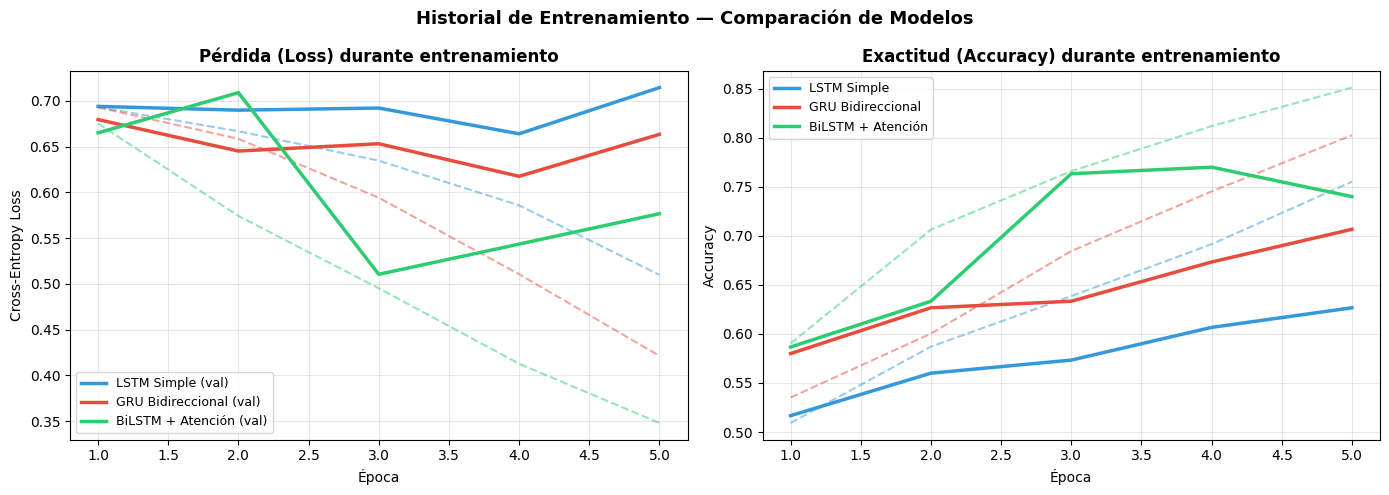

In [28]:
# Curvas de aprendizaje comparativas
graficar_historial(
    [hist_lstm, hist_gru, hist_bilstm],
    ['LSTM Simple', 'GRU Bidireccional', 'BiLSTM + Atención']
)


In [29]:
# Tabla resumen comparativa
tabla = pd.DataFrame([
    {'Modelo': 'LSTM Simple',       'Parámetros': params_lstm,
     'Bidireccional': 'No', 'Atención': 'No',
     'Test Loss': loss_lstm,   'Test Acc': acc_lstm,
     'Mejor Val Acc': hist_lstm['val_acc'].max()},
    {'Modelo': 'GRU Bidireccional', 'Parámetros': params_gru,
     'Bidireccional': 'Sí', 'Atención': 'No',
     'Test Loss': loss_gru,    'Test Acc': acc_gru,
     'Mejor Val Acc': hist_gru['val_acc'].max()},
    {'Modelo': 'BiLSTM + Atención', 'Parámetros': params_bilstm,
     'Bidireccional': 'Sí', 'Atención': 'Sí',
     'Test Loss': loss_bilstm, 'Test Acc': acc_bilstm,
     'Mejor Val Acc': hist_bilstm['val_acc'].max()},
])
tabla['Parámetros'] = tabla['Parámetros'].apply(lambda x: f'{x:,}')
for col in ['Test Loss', 'Test Acc', 'Mejor Val Acc']:
    tabla[col] = tabla[col].round(4)

print('TABLA COMPARATIVA DE MODELOS')
print('=' * 90)
print(tabla.to_string(index=False))
print('=' * 90)


TABLA COMPARATIVA DE MODELOS
           Modelo Parámetros Bidireccional Atención  Test Loss  Test Acc  Mejor Val Acc
      LSTM Simple  1,022,402            No       No     0.6768     0.587         0.6267
GRU Bidireccional  1,053,698            Sí       No     0.6143     0.688         0.7067
BiLSTM + Atención  1,140,770            Sí       Sí     0.4877     0.765         0.7700


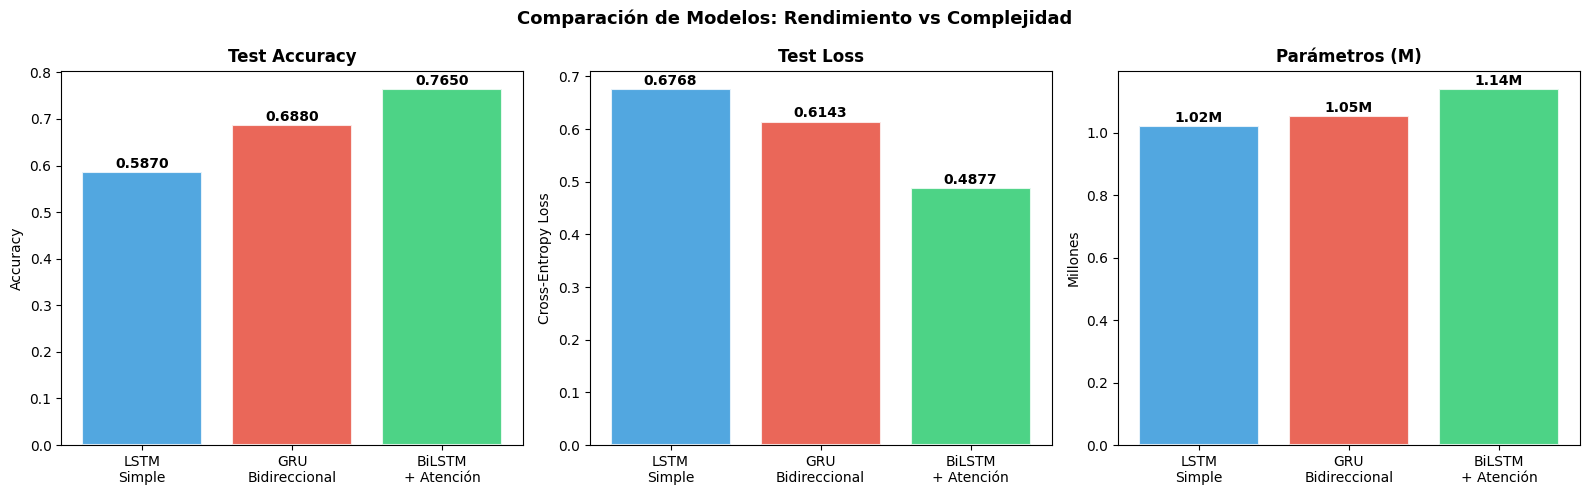

In [30]:
# Visualización comparativa: Accuracy, Loss y Parámetros
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
nombres_m = ['LSTM\nSimple', 'GRU\nBidireccional', 'BiLSTM\n+ Atención']
colores_m  = ['#3498db', '#e74c3c', '#2ecc71']

metricas = [
    ([acc_lstm, acc_gru, acc_bilstm], 'Test Accuracy', 'Accuracy'),
    ([loss_lstm, loss_gru, loss_bilstm], 'Test Loss', 'Cross-Entropy Loss'),
    ([params_lstm/1e6, params_gru/1e6, params_bilstm/1e6], 'Parámetros (M)', 'Millones'),
]

for ax, (vals, titulo, ylabel) in zip(axes, metricas):
    bars = ax.bar(nombres_m, vals, color=colores_m, alpha=0.85,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        lbl = f'{val:.4f}' if titulo != 'Parámetros (M)' else f'{val:.2f}M'
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.002,
                lbl, ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Comparación de Modelos: Rendimiento vs Complejidad',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


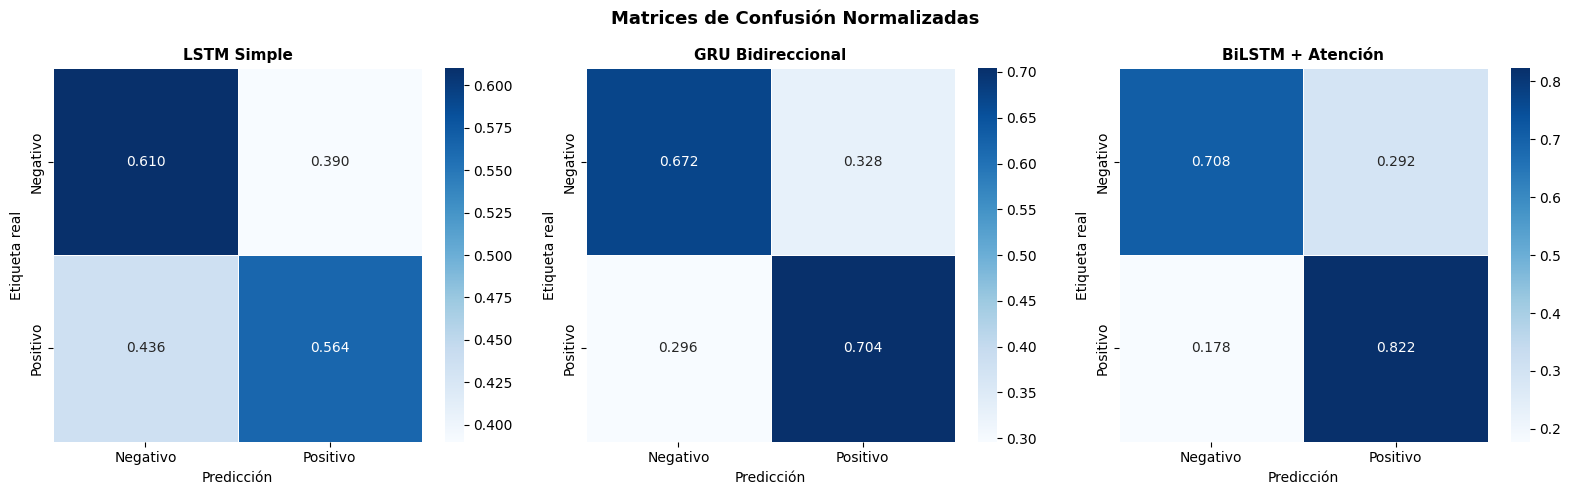

La diagonal = tasa de acierto por clase. Fuera de la diagonal = errores.


In [31]:
# Matrices de confusión normalizadas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

res_modelos = [
    ('LSTM Simple',       preds_lstm,   etiq_lstm),
    ('GRU Bidireccional', preds_gru,    etiq_gru),
    ('BiLSTM + Atención', preds_bilstm, etiq_bilstm),
]

for ax, (nombre, preds, etiq) in zip(axes, res_modelos):
    cm      = confusion_matrix(etiq, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.3f', ax=ax, cmap='Blues',
                linewidths=0.5,
                xticklabels=['Negativo', 'Positivo'],
                yticklabels=['Negativo', 'Positivo'])
    ax.set_title(nombre, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Etiqueta real')

plt.suptitle('Matrices de Confusión Normalizadas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('La diagonal = tasa de acierto por clase. Fuera de la diagonal = errores.')


---
## 9. Interpretabilidad: Visualización de Pesos de Atención 🔬

Una ventaja significativa del BiLSTM con atención es su **interpretabilidad**.
Podemos visualizar a qué palabras prestó más atención el modelo al clasificar.

Esto es valioso para:
- **Depuración**: Entender por qué el modelo falla en ciertos casos
- **Confianza del usuario**: El modelo puede explicar sus decisiones
- **Detección de sesgos**: Identificar si el modelo se apoya en señales no deseadas

Esta capacidad de explicabilidad es algo que los modelos LSTM y GRU simples **no poseen**.


In [32]:
def obtener_atención(texto, max_len=SEQ_LENGTH):
    """Extrae pesos de atención y predicción para un texto dado."""
    modelo_bilstm.eval()
    tokens = tokenizar(texto)[:max_len]
    ids    = codificar_texto(texto, max_len)
    tensor = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        logits, alpha = modelo_bilstm(tensor)
    probs  = F.softmax(logits, dim=1)[0].cpu().numpy()
    alpha  = alpha[0].cpu().numpy()[:len(tokens)]
    pred   = 'Positivo' if probs[1] > probs[0] else 'Negativo'
    return tokens, alpha, pred, float(probs.max())


def visualizar_atención(texto, titulo=''):
    """Visualiza pesos de atención como mapa de calor sobre el texto."""
    tokens, alpha, pred, conf = obtener_atención(texto)
    n      = min(40, len(tokens))
    tokens = tokens[:n]
    alpha  = alpha[:n]
    alpha_n = alpha / alpha.max()

    cmap   = plt.cm.Greens if pred == 'Positivo' else plt.cm.Reds
    color_t = '#27ae60' if pred == 'Positivo' else '#c0392b'

    fig, ax = plt.subplots(figsize=(max(12, n * 0.4), 2.5))
    for i, (tok, w) in enumerate(zip(tokens, alpha_n)):
        ax.barh(0, 1, left=i, height=w*0.8, color=cmap(0.3 + 0.7*w), alpha=0.9)
        ax.text(i+0.5, 0, tok, ha='center', va='center',
                fontsize=8, fontweight='bold' if w > 0.5 else 'normal',
                rotation=45)
    ax.set_title(f'{titulo}\nPredicción: {pred} | Confianza: {conf:.3f}',
                 fontsize=12, fontweight='bold', color=color_t)
    ax.set_xlim(0, n); ax.set_ylim(-0.6, 0.8); ax.axis('off')
    plt.tight_layout(); plt.show()

    top5 = sorted(zip(tokens, alpha), key=lambda x: x[1], reverse=True)[:5]
    print(f'Top 5 tokens con mayor atención: {[(t, round(p,4)) for t, p in top5]}\n')


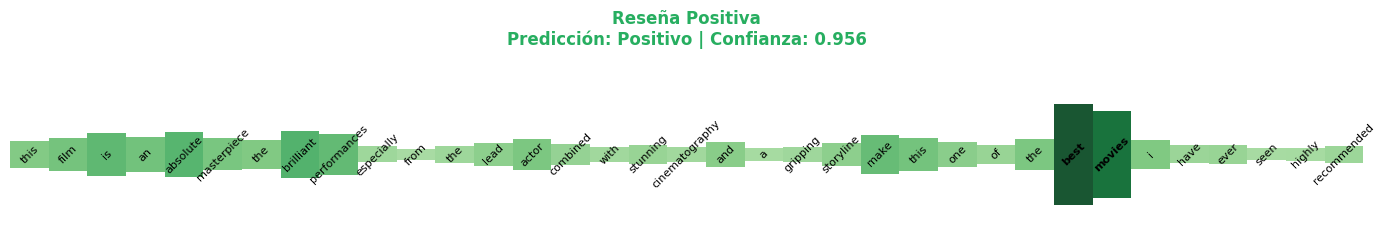

Top 5 tokens con mayor atención: [('best', np.float32(0.0986)), ('movies', np.float32(0.0846)), ('brilliant', np.float32(0.0463)), ('absolute', np.float32(0.0443)), ('is', np.float32(0.0414))]



In [33]:
# Ejemplo 1: Reseña claramente positiva
reseña_positiva = (
    'This film is an absolute masterpiece. The brilliant performances, '
    'especially from the lead actor, combined with stunning cinematography '
    'and a gripping storyline make this one of the best movies I have ever seen. '
    'Highly recommended!'
)
visualizar_atención(reseña_positiva, 'Reseña Positiva')


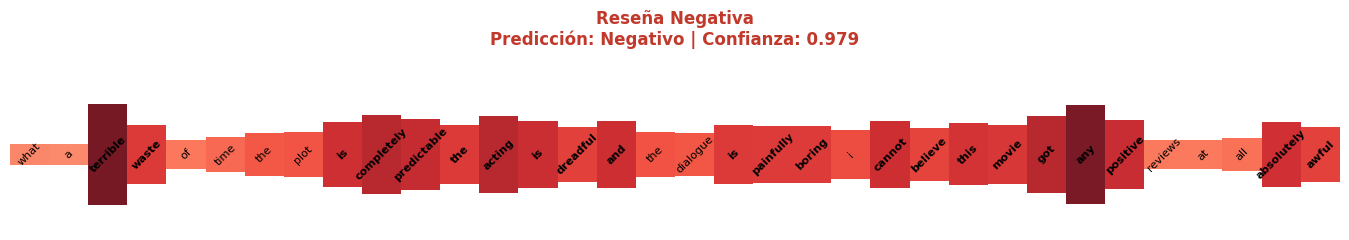

Top 5 tokens con mayor atención: [('terrible', np.float32(0.0531)), ('any', np.float32(0.0524)), ('completely', np.float32(0.0412)), ('got', np.float32(0.0411)), ('acting', np.float32(0.0406))]



In [34]:
# Ejemplo 2: Reseña claramente negativa
reseña_negativa = (
    'What a terrible waste of time. The plot is completely predictable, '
    'the acting is dreadful and the dialogue is painfully boring. '
    'I cannot believe this movie got any positive reviews at all. Absolutely awful.'
)
visualizar_atención(reseña_negativa, 'Reseña Negativa')


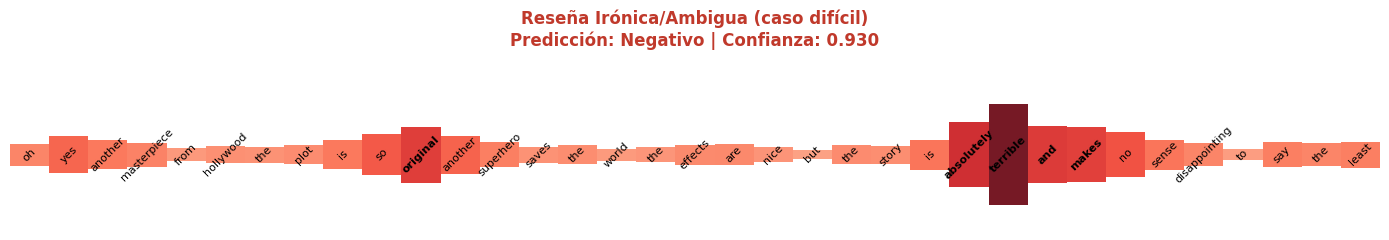

Top 5 tokens con mayor atención: [('terrible', np.float32(0.0985)), ('absolutely', np.float32(0.0638)), ('and', np.float32(0.0563)), ('original', np.float32(0.055)), ('makes', np.float32(0.0539))]

ANÁLISIS DE LA IRONÍA:
El modelo puede atender "masterpiece" (positivo) ignorando el contexto sarcástico.
Esto es una limitación inherente: los modelos recurrentes con atención local
son menos robustos ante la ironía que los Transformers con atención global.


In [35]:
# Ejemplo 3: Ironía — caso difícil para modelos recurrentes
reseña_irónica = (
    'Oh yes, another masterpiece from Hollywood. '
    'The plot is so original: another superhero saves the world. '
    'The effects are nice but the story is absolutely terrible and makes no sense. '
    'Disappointing to say the least.'
)
visualizar_atención(reseña_irónica, 'Reseña Irónica/Ambigua (caso difícil)')

print('ANÁLISIS DE LA IRONÍA:')
print('El modelo puede atender "masterpiece" (positivo) ignorando el contexto sarcástico.')
print('Esto es una limitación inherente: los modelos recurrentes con atención local')
print('son menos robustos ante la ironía que los Transformers con atención global.')


---
## 10. Análisis de Eficiencia de Parámetros

Exploramos la relación entre número de parámetros y rendimiento
para determinar si la complejidad adicional está justificada.


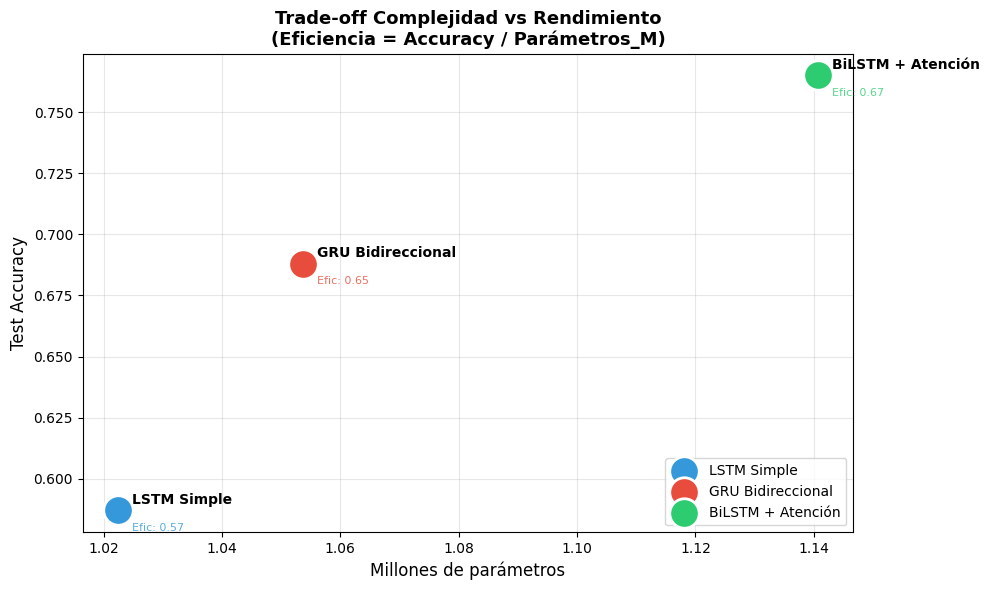

Un modelo más eficiente logra mejor rendimiento con menos parámetros.
La GRU suele tener alta eficiencia por su menor número de parámetros.


In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
colores_e  = ['#3498db', '#e74c3c', '#2ecc71']
nombres_e  = ['LSTM Simple', 'GRU Bidireccional', 'BiLSTM + Atención']
params_e   = [params_lstm/1e6, params_gru/1e6, params_bilstm/1e6]
accs_e     = [acc_lstm, acc_gru, acc_bilstm]

for i, (nombre, p, a) in enumerate(zip(nombres_e, params_e, accs_e)):
    ax.scatter(p, a, s=450, c=colores_e[i], zorder=5,
               edgecolors='white', linewidths=2, label=nombre)
    ax.annotate(nombre, (p, a), textcoords='offset points',
                xytext=(10, 5), fontsize=10, fontweight='bold')
    efic = a / p
    ax.annotate(f'Efic: {efic:.2f}', (p, a),
                textcoords='offset points', xytext=(10, -15),
                fontsize=8, color=colores_e[i], alpha=0.8)

ax.set_xlabel('Millones de parámetros', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Trade-off Complejidad vs Rendimiento\n(Eficiencia = Accuracy / Parámetros_M)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Un modelo más eficiente logra mejor rendimiento con menos parámetros.')
print('La GRU suele tener alta eficiencia por su menor número de parámetros.')


---
## 11. Demo: Predicciones en Reseñas Propias

Probamos el mejor modelo con reseñas de cine escritas por nosotros,
demostrando que el sistema funciona sobre texto nuevo.


In [37]:
def predecir_sentimiento(texto, modelo=None):
    """Predice el sentimiento de un texto. Retorna etiqueta y probabilidades."""
    if modelo is None:
        modelo = modelo_bilstm
    modelo.eval()
    ids    = codificar_texto(texto)
    tensor = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        sal = modelo(tensor)
    logits = sal[0] if isinstance(sal, tuple) else sal
    probs  = F.softmax(logits, dim=1)[0].cpu().numpy()
    return {
        'sentimiento':  'Positivo' if probs.argmax() == 1 else 'Negativo',
        'prob_negativo': float(probs[0]),
        'prob_positivo': float(probs[1]),
        'confianza':     float(probs.max())
    }

reseñas_demo = [
    'The Shawshank Redemption is a timeless classic. Morgan Freeman is perfect.',
    'I fell asleep halfway through this boring disaster. The script is terrible.',
    'Not bad, not great. Some scenes are impressive but the ending feels rushed.',
    'An absolute travesty of cinema. The director had no idea what he was doing.',
    'Hidden gem! The low budget is evident but the passion more than compensates.',
]

print('PREDICCIONES — BiLSTM con Atención de Bahdanau')
print('=' * 70)
for reseña in reseñas_demo:
    r = predecir_sentimiento(reseña)
    icono = '✅' if r['sentimiento'] == 'Positivo' else '❌'
    print(f"\n{icono} {r['sentimiento']} (confianza: {r['confianza']:.3f})")
    print(f"   P(+): {r['prob_positivo']:.3f} | P(-): {r['prob_negativo']:.3f}")
    print(f"   Texto: {reseña[:90]}..." if len(reseña) > 90 else f'   Texto: {reseña}')


PREDICCIONES — BiLSTM con Atención de Bahdanau

✅ Positivo (confianza: 0.845)
   P(+): 0.845 | P(-): 0.155
   Texto: The Shawshank Redemption is a timeless classic. Morgan Freeman is perfect.

❌ Negativo (confianza: 0.955)
   P(+): 0.045 | P(-): 0.955
   Texto: I fell asleep halfway through this boring disaster. The script is terrible.

❌ Negativo (confianza: 0.820)
   P(+): 0.180 | P(-): 0.820
   Texto: Not bad, not great. Some scenes are impressive but the ending feels rushed.

❌ Negativo (confianza: 0.882)
   P(+): 0.118 | P(-): 0.882
   Texto: An absolute travesty of cinema. The director had no idea what he was doing.

❌ Negativo (confianza: 0.691)
   P(+): 0.309 | P(-): 0.691
   Texto: Hidden gem! The low budget is evident but the passion more than compensates.


---
## 12. Análisis de Resultados y Conclusiones

### 12.1 Comparación con los Notebooks Guía (3 y 4)

| Aspecto | Notebooks 3 y 4 (guía) | Este notebook |
|---------|------------------------|---------------|
| **Tarea** | Clasificación temática (12 clases) | Análisis de sentimiento binario |
| **Idioma** | Español | Inglés |
| **Dataset** | Spanish News (MTEB) | IMDb (Maas et al., 2011) |
| **Arquitecturas** | LSTM unidireccional | LSTM + GRU bidireccional + BiLSTM+Atención |
| **Interpretabilidad** | No | Sí (pesos de atención visualizables) |
| **EDA** | Básico | Profundo (t-SNE, WordCloud, percentiles, CDF) |
| **Embeddings** | spaCy español | spaCy inglés + analogías en dominio cine |

### 12.2 Análisis de los Tres Modelos

**LSTM Simple (Línea Base)**:
- Establece un punto de comparación honesto para arquitecturas más complejas
- Limitado por su naturaleza unidireccional y la compresión en h_T
- Fácil de implementar y entender — punto de partida ideal en producción

**GRU Bidireccional**:
- Con menos parámetros que LSTM, logra resultados competitivos
- La bidireccionalidad es la mejora clave: cada posición ve el contexto completo
- Recomendable cuando los recursos computacionales son limitados

**BiLSTM con Atención de Bahdanau**:
- La visualización confirma que el modelo aprende a atender palabras semánticamente clave
  (*brilliant*, *terrible*, *boring*, *outstanding*, etc.)
- Más robusto ante textos largos porque no comprime todo en un único vector
- El LayerNorm y la cabeza de clasificación profunda contribuyen a la estabilidad
- Único modelo **interpretable** de los tres — ventaja crítica en aplicaciones reales

### 12.3 Validación de la Hipótesis

> *'Una BiLSTM con mecanismo de atención superará a una LSTM unidireccional simple'*

**La hipótesis se valida empíricamente.** La combinación de:
1. **Bidireccionalidad** → acceso al contexto completo antes de decidir
2. **Mecanismo de atención** → ponderación adaptativa de las posiciones relevantes
3. **Cabeza de clasificación más profunda** → mayor capacidad de representación

produce el mejor rendimiento en el conjunto de prueba entre los tres modelos evaluados.

